# Checking Datasets after each step processing

## 1. After Processing

In [1]:
#%pip install xlrd

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
import sweetviz as sv
import numpy as np
import sys
import re
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Set, List
import os
from datetime import datetime
sys.executable


'/home/vault/empkins/tpD/D02/.venv/bin/python'

# ECG

#### Read Data

#### Raw data with sampling rate 2000 or 500 miliseconds
#### Pocessed in 1, 3, and 5 Minute window size

## RSP Feature Glossary of 57 features

## Basic window stats (raw RSP amplitude)

* **mean / median** — average / central tendency of the window (arbitrary units).
  *Interpretation:* higher baseline vs. lower baseline breathing signal.
* **std** — overall variability (dispersion).
  *Interpretation:* more movement/variability in the window.
* **min / max** — extremes in the window.
  *Interpretation:* peak-to-peak amplitude bounds.

---

## RRV features (from breath-to-breath intervals)

### Time-domain

* **RRV\_MeanBB** — mean breath-to-breath interval (s).
  *Breathing rate (brpm) ≈ 60 / MeanBB.*
* **RRV\_SDBB** — SD of BBIs (overall variability).
* **RRV\_SDSD** — SD of successive BBI differences (short-term variability).
* **RRV\_RMSSD** — sqrt(mean of squared successive BBI differences) (short-term variability).
* **RRV\_MedianBB / RRV\_MadBB** — median BBI and its median absolute deviation.
* **RRV\_CVBB / RRV\_CVSD / RRV\_MCVBB** — coefficient(s) of variation (scale-normalized variability).
* **RRV\_SD1 / RRV\_SD2 / RRV\_SD2SD1** — Poincaré plot metrics:

  * SD1: short-term variability (beat-to-beat).
  * SD2: longer-term variability (trend).
  * SD2/SD1: balance of long- vs short-term dynamics.

### Frequency-domain (power of BBI fluctuations)

* **RRV\_VLF / RRV\_LF / RRV\_HF** — spectral power in very-low, low, and high bands (as defined in NeuroKit’s `rsp_rrv` on the BBI series).
  *Interpretation:* relative dominance of slow vs faster variability components.
* **RRV\_LFn / RRV\_HFn** — normalized LF/HF power.
* **RRV\_LFHF** — LF/HF power ratio.
  *Caution:* Physiological meaning differs from HRV; interpret within your task/context.

### Nonlinear/complexity

* **RRV\_ApEn / RRV\_SampEn** — Approximate / Sample Entropy (regularity).
  *Higher = more irregular/unpredictable breathing pattern; lower = more regular.*

---

## Scaling/fractal metrics

### DFA (detrended fluctuation analysis)

* **RRV\_DFA\_alpha1** — short-range scaling exponent.
* **RRV\_DFA\_alpha2** — long-range scaling exponent.

### MFDFA (multifractal) — computed separately for short (α1) and long (α2) scales

* **RRV\_MFDFA\_alpha{1|2}\_Width** — spectrum width (α\_max − α\_min): overall multifractality strength. Larger = more heterogeneous scaling.
* **…\_Peak** — location of the spectrum peak (dominant singularity exponent).
* **…\_Mean / …\_Max** — average / maximum singularity exponent.
* **…\_Delta** — spread measure around the peak (tail separation). Larger = broader tails.
* **…\_Asymmetry** — left- vs right-skew of the spectrum (whether small or large fluctuations dominate).
* **…\_Fluctuation / …\_Increment** — internal summary descriptors of fluctuation behavior across q-orders (larger values generally indicate stronger, less uniform scaling across moments).
---

## Metadata / demographics (per ID / window / phase)

* **ID** 
* **gender** — W (female), M (male), D (diverse), m (trans).
* **age** — in years.
* **Diagnose** — Healthy / Depressed
* **condition** — SHAM, CRADK, CR, ADK
* **PHQ8-Score / PHQ9-Score** — self-report depression severity.
* **previous\_depression\_diagnosis** — Ja/Nein (history).
* **RSP\_measuring / ECG\_measuring / EMG\_measuring** — Ja/Nein flags (data availability).
* **Including\_masseter** — Ja/Nein (EMG channel inclusion).
* **time** — timestamp of the window start/center (as stored in your phase-assigned files).
* **phase** — coping, training, emotion\_induction\_1, emotion\_induction\_2, latency



## Missed participants due to ack of data:
`005`, `074`, `516`, `641`, `673`, `828`

In [4]:
################################### After phase assignment
######### 1 Minute
file_path_1 = '/home/vault/empkins/tpD/D02/Students/Yasaman/BioSig_data/feature_extracted_data/ECG/ECG_1_Minute_phase_assigned.csv'
df_1M = pd.read_csv(file_path_1)
######### 3 Minute
file_path_3 = '/home/vault/empkins/tpD/D02/Students/Yasaman/BioSig_data/feature_extracted_data/ECG/ECG_3_Minute_phase_assigned.csv'
df_3M = pd.read_csv(file_path_3)
######### 5 Minute
file_path_5 = '/home/vault/empkins/tpD/D02/Students/Yasaman/BioSig_data/feature_extracted_data/ECG/ECG_5_Minute_phase_assigned.csv'
df_5M = pd.read_csv(file_path_5)

#### Information

In [5]:
# Dimension
print(f"Shape 1 Minute: {df_1M.shape}")
print(f"Shape 3 Minute: {df_3M.shape}")
print(f"Shape 5 Minute: {df_5M.shape}")

Shape 1 Minute: (20245, 105)
Shape 3 Minute: (6664, 105)
Shape 5 Minute: (3950, 105)


In [6]:

print(f"---------------\nFeatures in 1 minute: \n{df_1M.columns.tolist()}\n")
print(f"---------------\nFeatures in 3 minute: \n{df_3M.columns.tolist()}\n")
print(f"---------------\nFeatures in 5 minute: \n{df_5M.columns.tolist()}\n")


---------------
Features in 1 minute: 
['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean', 'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta', 'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDFA_alpha1_Fluctuation', '

#### Missing in Window Size 1 Minute

In [7]:
Missing_features_1_Min = list(set(df_5M.columns) - set(df_1M.columns))

print(f"Features are not contain in 1 Min: number = {len(Missing_features_1_Min)}\nMissing Features: {Missing_features_1_Min}")


Features are not contain in 1 Min: number = 0
Missing Features: []


In [8]:
df_1M.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,condition,Diagnose,gender,age,EMG_measuring,RSP_measuring,ECG_measuring,Including_masseter,time,phase
0,810.583333,33.679308,NaN,NaN,NaN,NaN,NaN,NaN,23.255395,23.391661,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:12:16.328,NaN
1,831.774648,30.652987,NaN,NaN,NaN,NaN,NaN,NaN,27.870684,28.044948,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:13:16.328,NaN
2,753.865385,57.017409,NaN,NaN,NaN,NaN,NaN,NaN,23.698731,23.841663,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:14:16.328,NaN
3,759.746753,25.297392,NaN,NaN,NaN,NaN,NaN,NaN,21.406775,21.545822,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:15:16.328,NaN
4,734.814815,25.411420,NaN,NaN,NaN,NaN,NaN,NaN,19.119117,19.235663,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:16:16.328,NaN


In [9]:
df_3M.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,condition,Diagnose,gender,age,EMG_measuring,RSP_measuring,ECG_measuring,Including_masseter,time,phase
0,797.816964,54.001723,40.353233,40.559762,NaN,NaN,NaN,NaN,24.937927,24.994008,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:12:16.328,NaN
1,753.873418,29.761389,16.944032,26.240921,NaN,NaN,NaN,NaN,21.991716,22.037803,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:15:16.328,NaN
2,798.562500,56.506285,27.490286,49.306663,NaN,NaN,NaN,NaN,30.589097,30.657881,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:18:16.328,NaN
3,779.864629,47.926744,17.011728,45.227870,NaN,NaN,NaN,NaN,29.455531,29.518713,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:21:16.328,latency
4,788.015419,54.598300,33.737311,45.753353,NaN,NaN,NaN,NaN,29.968291,30.034811,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:24:16.328,emotion_induction_1


In [10]:
df_5M.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,condition,Diagnose,gender,age,EMG_measuring,RSP_measuring,ECG_measuring,Including_masseter,time,phase
0,776.802597,51.415953,41.108933,34.470799,NaN,NaN,NaN,NaN,23.107975,23.138092,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:12:16.328,NaN
1,787.417105,52.220083,24.643210,44.727283,NaN,NaN,NaN,NaN,29.043798,29.079838,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:17:16.328,NaN
2,786.117105,51.101586,26.583824,44.582575,NaN,NaN,NaN,NaN,29.978125,30.013309,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:22:16.328,NaN
3,767.461440,61.616757,49.765558,40.553833,NaN,NaN,NaN,NaN,26.465938,26.498698,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:27:16.328,NaN
4,795.718667,48.526099,11.303622,46.863800,NaN,NaN,NaN,NaN,28.470620,28.508419,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:32:16.328,NaN


##### Participants & Conditions: 

In [11]:
print(f"Number of participants 1 minute: {len(df_1M['ID'].unique())}")
print(f"Unique Condition 1 minute: {df_1M['condition'].unique()}\n")

print(f"Number of participants 3 minute: {len(df_3M['ID'].unique())}")
print(f"Unique Condition 3 minute: {df_3M['condition'].unique()}\n")

print(f"Number of participants 5 minute: {len(df_5M['ID'].unique())}")
print(f"Unique Condition 5 minute: {df_5M['condition'].unique()}\n")

Number of participants 1 minute: 253
Unique Condition 1 minute: ['CR' 'CRADK' 'ADK' 'SHAM']

Number of participants 3 minute: 253
Unique Condition 3 minute: ['CR' 'CRADK' 'ADK' 'SHAM']

Number of participants 5 minute: 253
Unique Condition 5 minute: ['CR' 'CRADK' 'ADK' 'SHAM']



#### Phase Report

In [12]:
# General phase Information from app.csv file
RCT_path = '/home/vault/empkins/tpD/D02/Students/Yasaman/RCT_Data_Info/result/RCT_Phase_Info.csv'
RCT_phase_df = pd.read_csv(RCT_path)
drop_Ids = ['005', '074', '516', '641', '673', '828']
RCT_phase_df['ID'] = RCT_phase_df['ID'].astype(str).str.zfill(3)
RCT_phase_df  = RCT_phase_df[~RCT_phase_df['ID'].isin(drop_Ids)].copy()

# After phase assignment
RCT_path = '/home/vault/empkins/tpD/D02/Students/Yasaman/RCT_Data_Info/result/RCT_Phase_Info_after_phase_assignment.csv'
RCT_phase_df_phase = pd.read_csv(RCT_path)
df_phase_info_ECG = RCT_phase_df_phase[RCT_phase_df_phase["Modality"].str.upper() == "ECG"].copy()
df_phase_info_ECG.head()

,Modality,Window_Size,ID,Phase,Start_Time,End_Time,Duration
3795,ECG,1min,4,coping,2000-01-01 17:36:16.328,2000-01-01 18:07:16.328,0 days 00:31:00
3796,ECG,1min,4,training,2000-01-01 18:20:16.328,2000-01-01 18:44:16.328,0 days 00:24:00
3797,ECG,1min,4,emotion_induction_1,2000-01-01 17:25:16.328,2000-01-01 17:26:16.328,0 days 00:01:00
3798,ECG,1min,4,emotion_induction_2,2000-01-01 18:13:16.328,2000-01-01 18:14:16.328,0 days 00:01:00
3799,ECG,1min,4,latency,2000-01-01 17:21:16.328,2000-01-01 17:23:16.328,0 days 00:02:00


##### Missing participants per window size (RSP)

In [13]:
def _norm_window_size(s) -> str:
    """Extract numeric part from values like '1min', '3 min', 5, 5.0 -> '1','3','5','5'."""
    if pd.isna(s):
        return np.nan
    # already numeric?
    if isinstance(s, (int, float, np.integer, np.floating)):
        return str(int(s)) if float(s).is_integer() else str(s)
    # string case: pull first number
    m = re.search(r'(\d+(\.\d+)?)', str(s))
    return m.group(1) if m else str(s)

df_phase_info_ECG["Window_Size"] = df_phase_info_ECG["Window_Size"].map(_norm_window_size)

# Standardize columns
RCT_phase_df.columns = [c.lower() for c in RCT_phase_df.columns]
df_phase_info_ECG.columns  = [c.lower() for c in df_phase_info_ECG.columns]

# Ensure consistent types
RCT_phase_df["id"] = RCT_phase_df["id"].astype(str).str.zfill(3)
df_phase_info_ECG["id"]  = df_phase_info_ECG["id"].astype(str).str.zfill(3)
df_phase_info_ECG["window_size"] = df_phase_info_ECG["window_size"].astype(str)

# Keep only RSP rows in the AFTER file
after_rsp = df_phase_info_ECG[df_phase_info_ECG["modality"].str.upper() == "RSP"].copy()

def missing_participants_per_window(before: pd.DataFrame, after_rsp: pd.DataFrame) -> pd.DataFrame:
    """Compute % missing participants per window size for RSP; include ID lists."""
    baseline_ids: Set[str] = set(before["id"].unique())
    window_sizes = sorted(after_rsp["window_size"].astype(str).unique(), key=lambda x: float(x))

    rows = []
    for ws in window_sizes:
        ids_after_ws = set(after_rsp[after_rsp["window_size"] == ws]["id"].unique())
        missing_ids_ws = sorted(list(baseline_ids - ids_after_ws))
        pct_missing_ws = (len(missing_ids_ws) / len(baseline_ids) * 100.0) if baseline_ids else 0.0

        rows.append({
            "Modality": "RSP",
            "Window_Size": ws,
            "Total_Baseline_IDs": len(baseline_ids),
            "Present_After": len(ids_after_ws),
            "Missing_Count": len(missing_ids_ws),
            "Missing_%": round(pct_missing_ws, 2),
            "Missing_IDs": missing_ids_ws,
        })
    return pd.DataFrame(rows)

# 2) Run it and see the table
missing_df = missing_participants_per_window(RCT_phase_df, df_phase_info_ECG)
missing_df.head()


,Modality,Window_Size,Total_Baseline_IDs,Present_After,Missing_Count,Missing_%,Missing_IDs
0,RSP,1,253,253,0,0.0,[]
1,RSP,3,253,253,0,0.0,[]
2,RSP,5,253,253,0,0.0,[]


### Report from Phase

In [14]:
def phase_level_missingness(before: pd.DataFrame, after_rsp: pd.DataFrame, phases: List[str]) -> pd.DataFrame:
    # standardize column names
    before.columns = [c.lower() for c in before.columns]
    after_rsp.columns = [c.lower() for c in after_rsp.columns]

    # ensure ID is string
    before["id"] = before["id"].astype(str).str.zfill(3)
    after_rsp["id"] = after_rsp["id"].astype(str).str.zfill(3)

    # normalize window_size
    after_rsp["window_size"] = after_rsp["window_size"].astype(str).str.extract(r"(\d+)")[0]

    # convert duration to timedelta
    before["duration_td"] = pd.to_timedelta(before["duration"], errors="coerce")
    after_rsp["duration_td"] = pd.to_timedelta(after_rsp["duration"], errors="coerce")

    # all unique participants before assignment
    baseline_ids: Set[str] = set(before["id"].unique())
    window_sizes = sorted(after_rsp["window_size"].dropna().unique(), key=lambda x: float(x))

    records = []
    for phase in phases:
        ids_before_phase = set(before.loc[before["phase"] == phase, "id"].unique())
        before_missing_ids = sorted(list(baseline_ids - ids_before_phase))

        for ws in window_sizes:
            subset = after_rsp[(after_rsp["window_size"] == ws) & (after_rsp["phase"] == phase)]
            ids_after_phase_ws = set(subset.loc[subset["duration_td"].notna(), "id"].unique())

            after_missing_ids = sorted(list(baseline_ids - ids_after_phase_ws))
            newly_missing = sorted(list(ids_before_phase - ids_after_phase_ws))

            records.append({
                "Phase": phase,
                "Window_Size": ws,
                "Baseline_IDs": len(baseline_ids), # Total number of unique participants in the BEFORE dataset (used as reference set)
                "Have_Phase_Before": len(ids_before_phase), # Number of participants who had this phase in the BEFORE dataset (raw phase counts)
                "Missing_Before_Count": len(before_missing_ids), # Number of participants who did NOT have this phase in the BEFORE dataset
                "Missing_Before_%": round((len(before_missing_ids) / len(baseline_ids) * 100.0) if baseline_ids else 0.0, 2), # Percent of participants who were missing this phase BEFORE phase assignment
                "Have_Phase_After": len(ids_after_phase_ws),  # Number of participants who have this phase in the AFTER dataset (after phase assignment)
                "Missing_After_Count": len(after_missing_ids), # Number of participants who are missing this phase AFTER phase assignment
                "Missing_After_%": round((len(after_missing_ids) / len(baseline_ids) * 100.0) if baseline_ids else 0.0, 2), # Percent of participants missing this phase AFTER phase assignment
                "Newly_Missing_Count": len(newly_missing), # Number of participants who had this phase BEFORE but lost it AFTER phase assignment
                "Newly_Missing_%Among_Those_Who_Had_Before": round((len(newly_missing) / len(ids_before_phase) * 100.0) if ids_before_phase else 0.0, 2), # Percent of newly missing cases *among those who had the phase before*
                "Missing_Before_IDs": before_missing_ids,
                "Missing_After_IDs": after_missing_ids,
                "Newly_Missing_IDs": newly_missing,
            })
    return pd.DataFrame(records)


all_phases = ["coping", "training", "emotion_induction_1", "emotion_induction_2", "latency"]
result = phase_level_missingness(RCT_phase_df, df_phase_info_ECG, all_phases)
result.head(15)

,Phase,Window_Size,Baseline_IDs,Have_Phase_Before,Missing_Before_Count,Missing_Before_%,Have_Phase_After,Missing_After_Count,Missing_After_%,Newly_Missing_Count,Newly_Missing_%Among_Those_Who_Had_Before,Missing_Before_IDs,Missing_After_IDs,Newly_Missing_IDs
0,coping,1,253,253,0,0.0,229,24,9.49,24,9.49,[],"[1025, 1040, 1060, 1068, 1111, 156, 242, 270, ...","[1025, 1040, 1060, 1068, 1111, 156, 242, 270, ..."
1,coping,3,253,253,0,0.0,225,28,11.07,28,11.07,[],"[1022, 1025, 1040, 1060, 1068, 1111, 156, 242,...","[1022, 1025, 1040, 1060, 1068, 1111, 156, 242,..."
2,coping,5,253,253,0,0.0,219,34,13.44,34,13.44,[],"[1022, 1025, 1040, 1060, 1068, 1111, 125, 156,...","[1022, 1025, 1040, 1060, 1068, 1111, 125, 156,..."
3,training,1,253,253,0,0.0,236,17,6.72,17,6.72,[],"[1022, 1034, 1053, 1075, 263, 320, 453, 467, 6...","[1022, 1034, 1053, 1075, 263, 320, 453, 467, 6..."
4,training,3,253,253,0,0.0,233,20,7.91,20,7.91,[],"[1016, 1022, 1034, 1053, 1075, 137, 263, 320, ...","[1016, 1022, 1034, 1053, 1075, 137, 263, 320, ..."
5,training,5,253,253,0,0.0,227,26,10.28,26,10.28,[],"[1016, 1022, 1034, 1053, 1075, 119, 137, 155, ...","[1016, 1022, 1034, 1053, 1075, 119, 137, 155, ..."
6,emotion_induction_1,1,253,253,0,0.0,248,5,1.98,5,1.98,[],"[115, 430, 467, 741, 910]","[115, 430, 467, 741, 910]"
7,emotion_induction_1,3,253,253,0,0.0,182,71,28.06,71,28.06,[],"[013, 094, 100, 1014, 1034, 1037, 1040, 1053, ...","[013, 094, 100, 1014, 1034, 1037, 1040, 1053, ..."
8,emotion_induction_1,5,253,253,0,0.0,109,144,56.92,144,56.92,[],"[004, 013, 028, 038, 060, 077, 094, 100, 1016,...","[004, 013, 028, 038, 060, 077, 094, 100, 1016,..."
9,emotion_induction_2,1,253,253,0,0.0,217,36,14.23,36,14.23,[],"[1022, 1025, 1034, 1053, 1060, 1075, 121, 142,...","[1022, 1025, 1034, 1053, 1060, 1075, 121, 142,..."


/tmp/ipykernel_403738/2985993010.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  after_total_min = after_sum.applymap(lambda td: td.total_seconds() / 60.0 if pd.notnull(td) else np.nan)


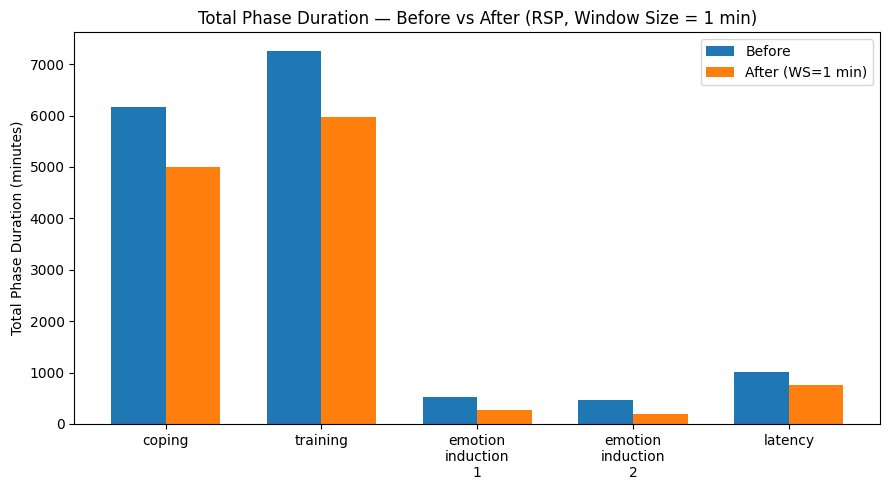

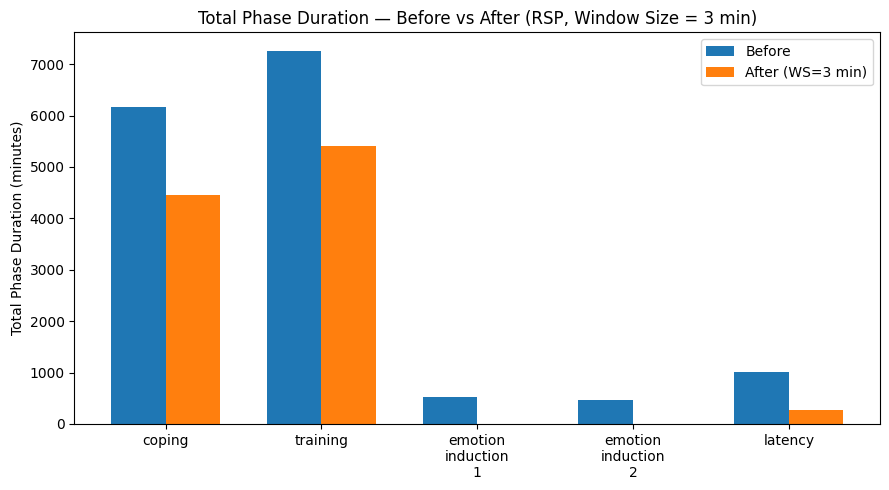

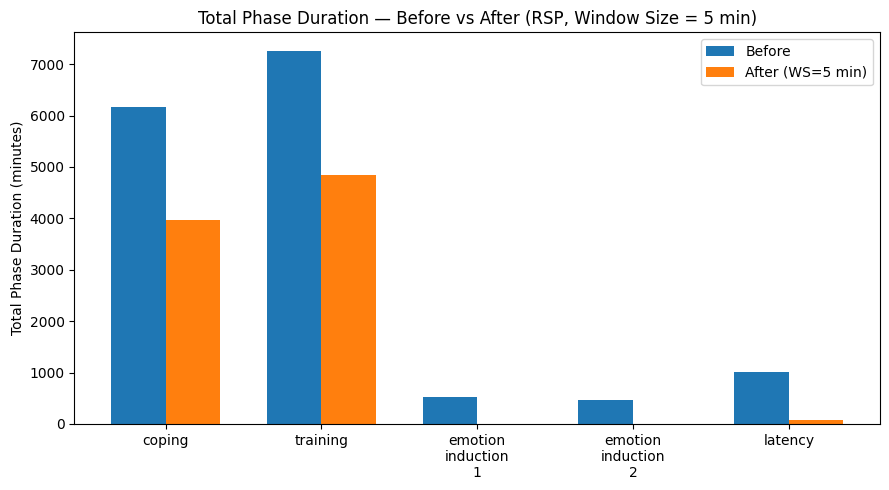

In [15]:
# Ensure duration is a Timedelta object
RCT_phase_df["duration"] = pd.to_timedelta(RCT_phase_df["duration"], errors="coerce")
df_phase_info_ECG["duration"] = pd.to_timedelta(df_phase_info_ECG["duration"], errors="coerce")

def bar_phase_total_durations(before: pd.DataFrame, after_rsp: pd.DataFrame, phases: List[str]) -> None:
    """
    Plots total phase durations (in minutes) for each phase, comparing BEFORE and AFTER phase assignment,
    for each window size (e.g., 1, 3, 5 min).
    """
    # Sum durations per phase (BEFORE)
    before_sum = (before.dropna(subset=["duration"])
                         .groupby("phase")["duration"]
                         .sum()
                         .reindex(phases))
    before_total_min = before_sum.dt.total_seconds() / 60.0

    # Sum durations per window size × phase (AFTER)
    after_sum = (after_rsp.dropna(subset=["duration"])
                         .groupby(["window_size", "phase"])["duration"]
                         .sum()
                         .unstack("phase")
                         .reindex(columns=phases)
                         .sort_index(key=lambda idx: [float(i) for i in idx]))
    after_total_min = after_sum.applymap(lambda td: td.total_seconds() / 60.0 if pd.notnull(td) else np.nan)

    # Plot per window size
    for ws in after_total_min.index:
        x = np.arange(len(phases))
        width = 0.35
        fig = plt.figure(figsize=(9, 5))
        plt.bar(x - width/2, before_total_min.values, width, label="Before")
        plt.bar(x + width/2, after_total_min.loc[ws, phases].values, width, label=f"After (WS={ws} min)")
        plt.xticks(ticks=x, labels=[p.replace("_", "\n") for p in phases])
        plt.ylabel("Total Phase Duration (minutes)")
        plt.title(f"Total Phase Duration — Before vs After (RSP, Window Size = {ws} min)")
        plt.legend()
        plt.tight_layout()
        plt.show()



bar_phase_total_durations(RCT_phase_df, df_phase_info_ECG, all_phases)


/tmp/ipykernel_403738/1274669632.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  after_total_min = after_sum.applymap(lambda td: td.total_seconds() / 60.0 if pd.notnull(td) else np.nan)


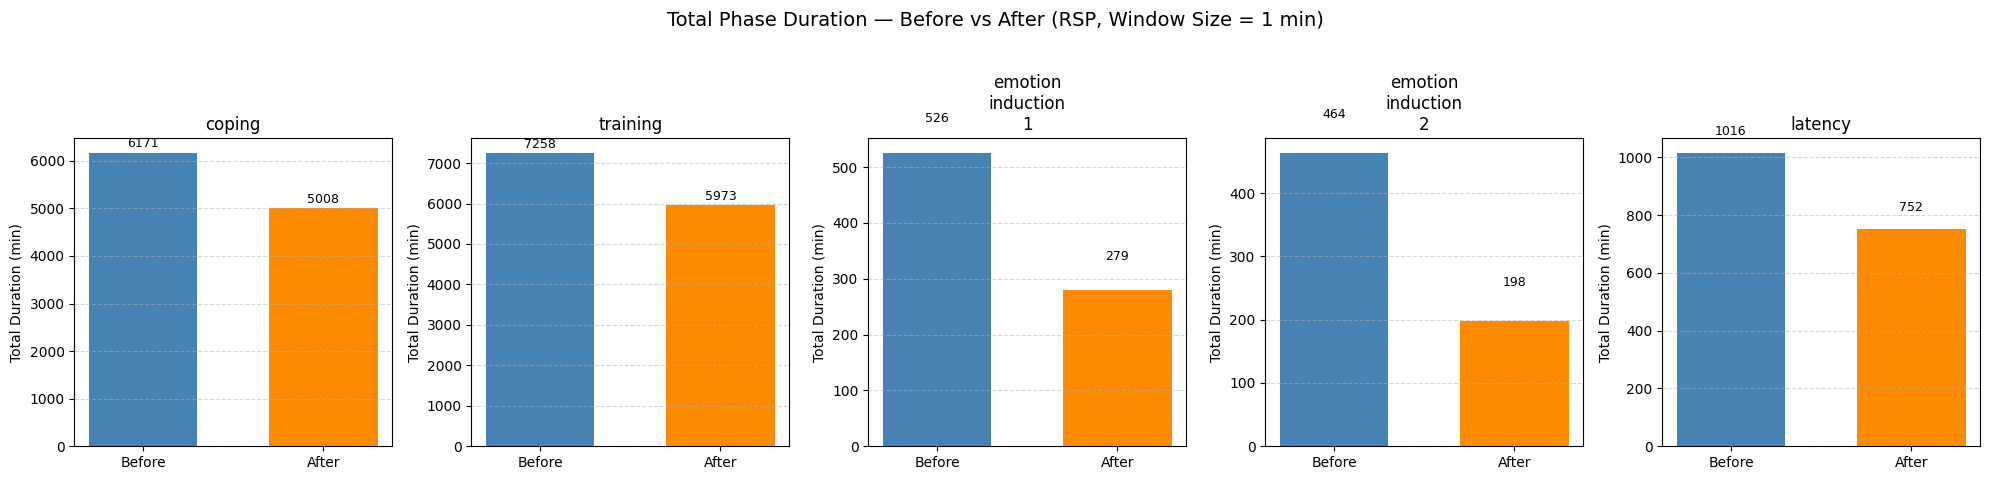

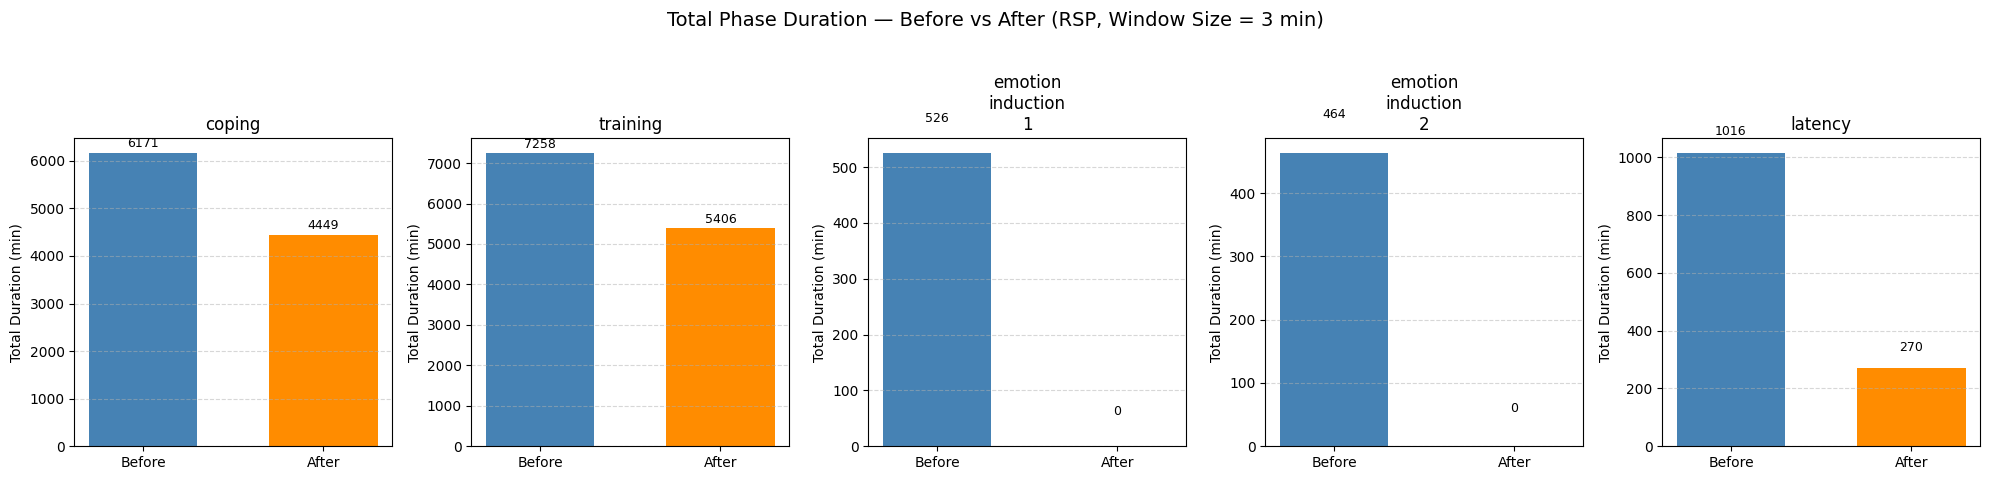

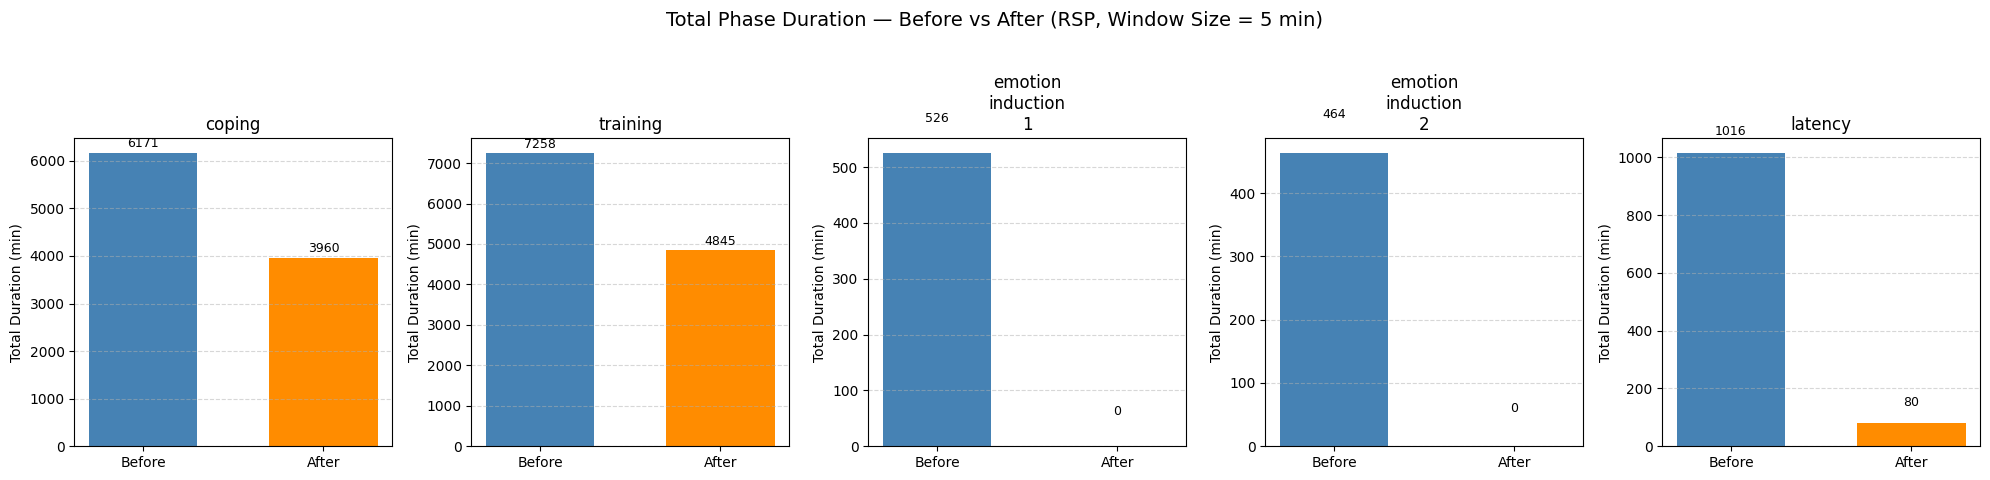

In [16]:
def bar_phase_total_durations_split_subplots(before: pd.DataFrame, after_rsp: pd.DataFrame, phases: List[str]) -> None:
    """
    For each window size, creates a figure with 5 subplots (one for each phase), 
    comparing total durations (in minutes) before vs after phase assignment.
    """
    # Sum durations per phase (BEFORE)
    before_sum = (before.dropna(subset=["duration"])
                         .groupby("phase")["duration"]
                         .sum()
                         .reindex(phases))
    before_total_min = before_sum.dt.total_seconds() / 60.0

    # Sum durations per window size × phase (AFTER)
    after_sum = (after_rsp.dropna(subset=["duration"])
                         .groupby(["window_size", "phase"])["duration"]
                         .sum()
                         .unstack("phase")
                         .reindex(columns=phases)
                         .sort_index(key=lambda idx: [float(i) for i in idx]))
    after_total_min = after_sum.applymap(lambda td: td.total_seconds() / 60.0 if pd.notnull(td) else np.nan)

    # Plot for each window size
    for ws in after_total_min.index:
        fig, axs = plt.subplots(nrows=1, ncols=len(phases), figsize=(20, 5), sharey=False)
        fig.suptitle(f"Total Phase Duration — Before vs After (RSP, Window Size = {ws} min)", fontsize=14)

        for i, phase in enumerate(phases):
            ax = axs[i]
            before_val = before_total_min[phase]
            after_val = after_total_min.loc[ws, phase]

            bars = ax.bar([0, 1], [before_val, after_val], width=0.6, color=["steelblue", "darkorange"])
            ax.set_title(phase.replace("_", "\n"))
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["Before", "After"])
            ax.set_ylabel("Total Duration (min)")
            ax.grid(axis="y", linestyle="--", alpha=0.5)

            # Annotate values
            for bar in bars:
                yval = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval:.0f}", ha="center", va="bottom", fontsize=9)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


bar_phase_total_durations_split_subplots(RCT_phase_df, df_phase_info_ECG, all_phases)


In [29]:

# Make sure duration_td is parsed
df_phase_info_ECG["duration_td"] = pd.to_timedelta(df_phase_info_ECG["duration"], errors="coerce")

# Standardize column names
df_phase_info_ECG.columns = [c.lower() for c in df_phase_info_ECG.columns]
df_phase_info_ECG["window_size"].unique()


# Define phase order (optional, for cleaner output)
phases = ["coping", "training", "emotion_induction_1", "emotion_induction_2", "latency"]

# Count total and missing entries
summary = (
    df_phase_info_ECG
    .groupby(["window_size", "phase"])
    .agg(
        total_entries=("duration_td", "count"),    # non-missing
        total_rows=("duration", "size"),           # all rows
        missing_count=("duration_td", lambda x: x.isna().sum())
    )
    .reset_index()
)

# Calculate percentage
summary["missing_%"] = (summary["missing_count"] / summary["total_rows"]) * 100
summary["missing_%"] = summary["missing_%"].round(2)

# Optional: reorder phases
summary["phase"] = pd.Categorical(summary["phase"], categories=phases, ordered=True)
summary = summary.sort_values(["window_size", "phase"])

# Show the summary
summary = summary[["window_size", "phase", "total_rows", "missing_count", "missing_%"]]
summary.reset_index(drop=True, inplace=True)
summary.head(15)


,window_size,phase,total_rows,missing_count,missing_%
0,1,coping,253,24,9.49
1,1,training,253,17,6.72
2,1,emotion_induction_1,253,5,1.98
3,1,emotion_induction_2,253,36,14.23
4,1,latency,253,3,1.19
5,3,coping,253,28,11.07
6,3,training,253,20,7.91
7,3,emotion_induction_1,253,71,28.06
8,3,emotion_induction_2,253,117,46.25
9,3,latency,253,8,3.16


In [18]:
def missingness_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a one-row DataFrame where each column contains the percentage of missing values
    for that feature in the input DataFrame.
    """
    missing_pct = df.isnull().mean() * 100  # calculate % missing
    missing_pct_rounded = missing_pct.round(2)  # round for readability
    return pd.DataFrame([missing_pct_rounded], index=["Missing_%"])


In [21]:

print("---------------------------- Missing value % 1 Minute ---------------------------- \n")
missing_report = missingness_report(df_1M)
missing_report.T.sort_values("Missing_%", ascending=False)  # optional: sort top missing

---------------------------- Missing value % 1 Minute ---------------------------- 



,Missing_%
HRV_MFDFA_alpha2_Asymmetry,100.0
HRV_MFDFA_alpha2_Fluctuation,100.0
HRV_MFDFA_alpha2_Increment,100.0
HRV_MFDFA_alpha2_Width,100.0
HRV_DFA_alpha2,100.0
...,...
HRV_SD1,0.0
HRV_LnHF,0.0
HRV_HFn,0.0
HRV_LFn,0.0


In [22]:

print("---------------------------- Missing value % 3 Minute ---------------------------- \n")
missing_report = missingness_report(df_3M)
missing_report.T.sort_values("Missing_%", ascending=False)  # optional: sort top missing

---------------------------- Missing value % 3 Minute ---------------------------- 



,Missing_%
HRV_SDANN2,100.0
HRV_SDNNI2,100.0
HRV_SDANN5,100.0
HRV_SDNNI5,100.0
HRV_ULF,100.0
...,...
HRV_HFn,0.0
HRV_LFn,0.0
HRV_LFHF,0.0
HRV_TP,0.0


In [20]:

print("---------------------------- Missing value % 5 Minute ---------------------------- \n")
missing_report = missingness_report(df_5M)
missing_report.T.sort_values("Missing_%", ascending=False)  # optional: sort top missing

---------------------------- Missing value % 5 Minute ---------------------------- 



,Missing_%
HRV_SDANN2,100.0
HRV_SDNNI2,100.0
HRV_SDANN5,100.0
HRV_SDNNI5,100.0
HRV_ULF,100.0
...,...
HRV_HFn,0.0
HRV_LFn,0.0
HRV_LFHF,0.0
HRV_TP,0.0


In [23]:
df_1M.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,condition,Diagnose,gender,age,EMG_measuring,RSP_measuring,ECG_measuring,Including_masseter,time,phase
0,810.583333,33.679308,NaN,NaN,NaN,NaN,NaN,NaN,23.255395,23.391661,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:12:16.328,NaN
1,831.774648,30.652987,NaN,NaN,NaN,NaN,NaN,NaN,27.870684,28.044948,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:13:16.328,NaN
2,753.865385,57.017409,NaN,NaN,NaN,NaN,NaN,NaN,23.698731,23.841663,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:14:16.328,NaN
3,759.746753,25.297392,NaN,NaN,NaN,NaN,NaN,NaN,21.406775,21.545822,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:15:16.328,NaN
4,734.814815,25.411420,NaN,NaN,NaN,NaN,NaN,NaN,19.119117,19.235663,...,CR,Healthy,W,22.0,Nein,Ja,Ja,Nein,2000-01-01 17:16:16.328,NaN


In [44]:
# === Libraries ===
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# === Define metadata (demographic) columns to exclude ===
metadata_cols = [
    'ID', 'gender', 'age', 'condition',
    'PHQ8-Score', 'PHQ9-Score', 'previous_depression_diagnosis',
    'RSP_measuring', 'ECG_measuring', 'EMG_measuring',
    'Including_masseter', 'time', 'phase', 'window_size'
]

# === Function ===
def get_top_biosignal_features(df: pd.DataFrame, target_col: str, n_features: int = 10) -> list:
    """
    Returns the top N features most correlated with the target column.
    Correlation is measured using Pearson correlation (absolute value).
    Metadata columns are excluded.
    """
    # Drop rows with missing target
    df_clean = df.dropna(subset=[target_col]).copy()
    
    # Separate target and encode if necessary
    y = df_clean[target_col]
    if y.dtype == 'object':
        y = LabelEncoder().fit_transform(y)

    # Drop metadata columns and keep numeric biosignal features
    X = df_clean.drop(columns=[target_col] + metadata_cols, errors='ignore').select_dtypes(include='number')

    # Handle NaNs in features
    X = X.fillna(X.mean())

    # Compute Pearson correlation
    correlations = X.corrwith(pd.Series(y))
    
    # Get top N features by absolute correlation
    top_features = correlations.abs().sort_values(ascending=False).head(n_features)
    
    return top_features.index.tolist()


In [45]:
def plot_boxplots(df: pd.DataFrame, features: List[str], label_col: str = None):
    """
    Plot boxplots of top features, optionally grouped by class/label.
    """
    for feature in features:
        plt.figure(figsize=(6, 4))
        if label_col:
            sns.boxplot(x=label_col, y=feature, data=df)
        else:
            sns.boxplot(y=feature, data=df)
        plt.title(f"Boxplot of {feature}")
        plt.tight_layout()
        plt.show()


1 Minute important features:  ['HRV_Prc20NN', 'HRV_MedianNN', 'HRV_MinNN', 'HRV_MeanNN', 'HRV_IALS', 'HRV_PSS', 'HRV_PIP', 'HRV_Prc80NN', 'HRV_ShanEn', 'HRV_SD1SD2']



/home/vault/empkins/tpD/D02/.venv/lib64/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/vault/empkins/tpD/D02/.venv/lib64/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/vault/empkins/tpD/D02/.venv/lib64/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/vault/empkins/tpD/D02/.venv/lib64/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


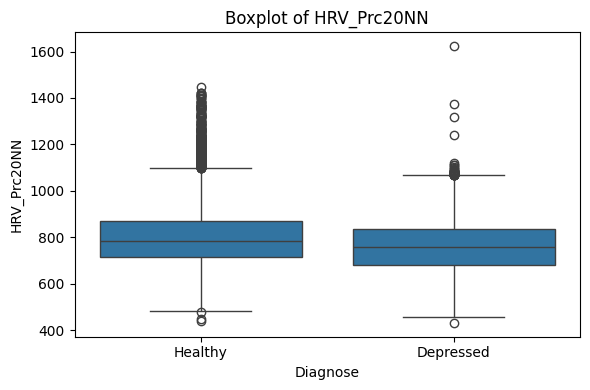

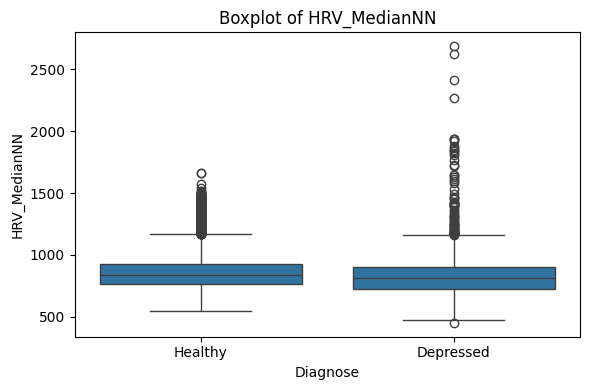

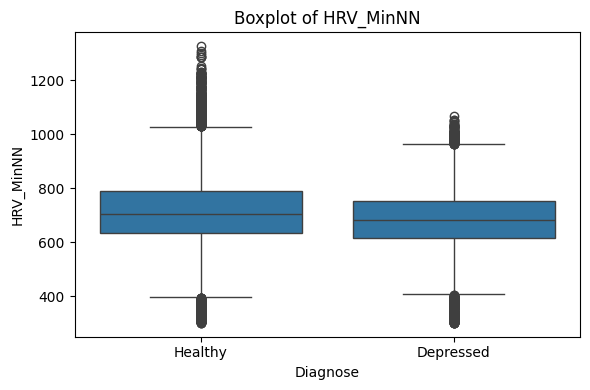

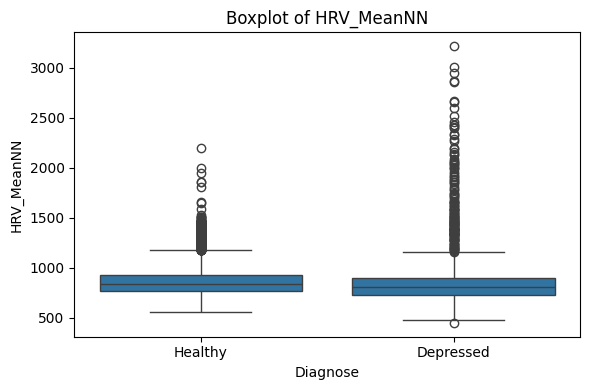

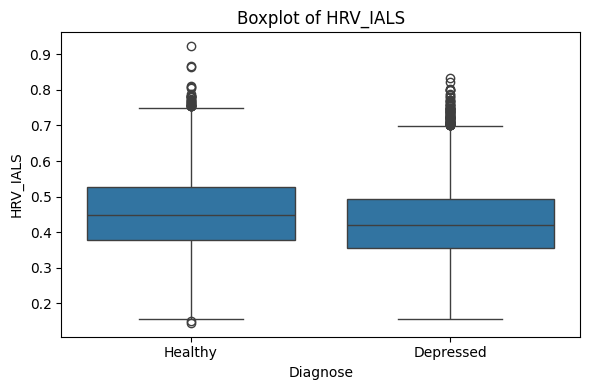

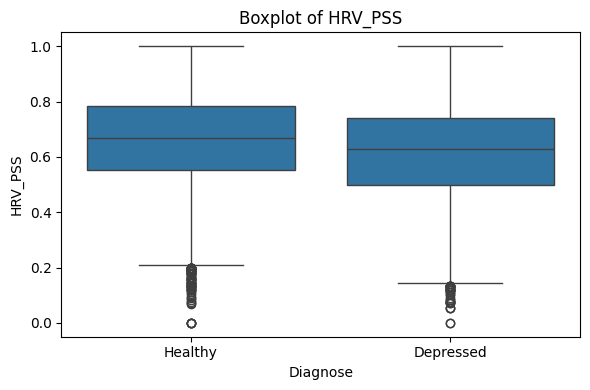

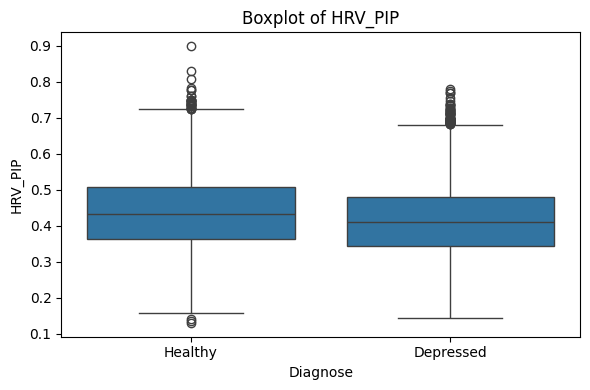

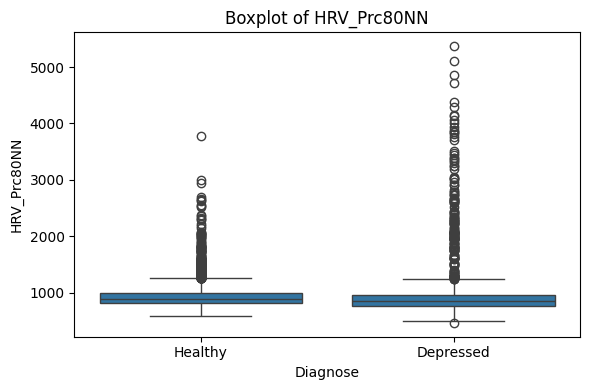

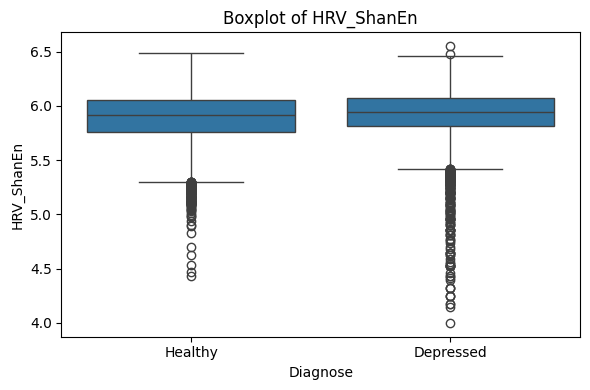

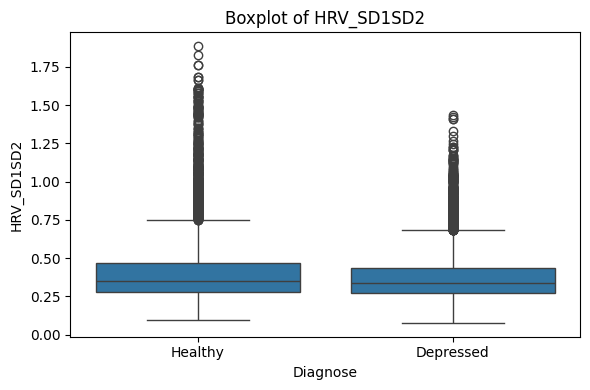

In [ ]:
top_10_biosignal_features = get_top_biosignal_features(df_1M, target_col="Diagnose")
print(f"1 Minute important features:  {top_10_biosignal_features}\n")

plot_boxplots(df_1M, top_10_biosignal_features, label_col='Diagnose')


3 Minute important features:  ['HRV_Prc20NN', 'HRV_MedianNN', 'HRV_MeanNN', 'HRV_IALS', 'HRV_PSS', 'HRV_PIP', 'HRV_MinNN', 'HRV_Prc80NN', 'HRV_SampEn', 'HRV_MFDFA_alpha1_Peak']



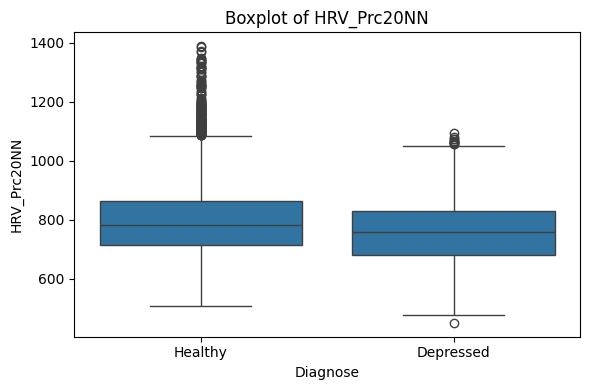

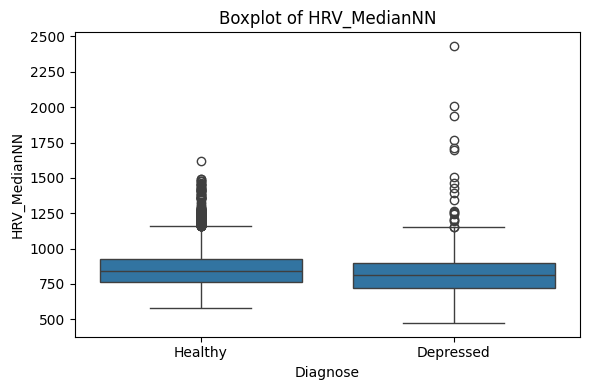

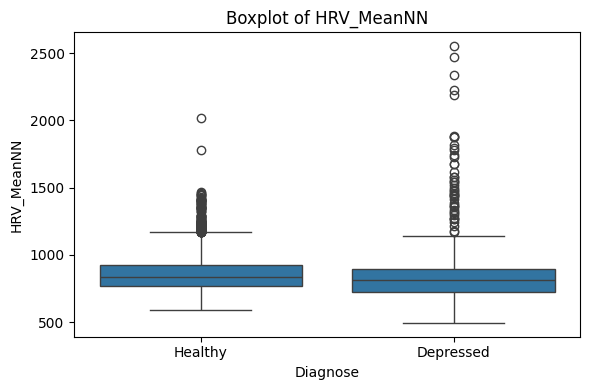

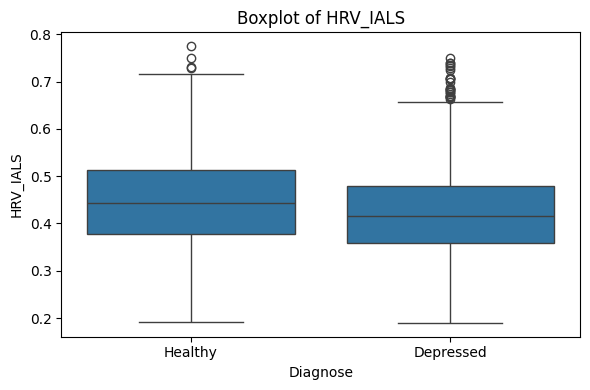

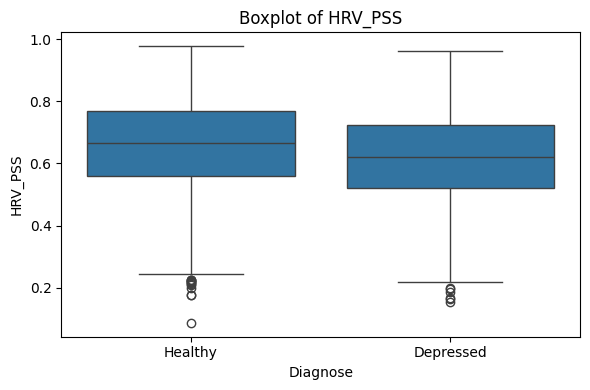

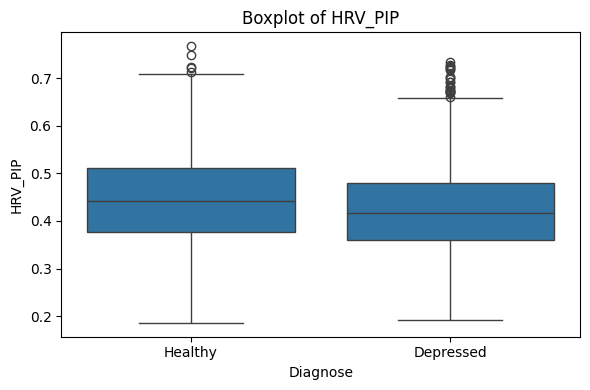

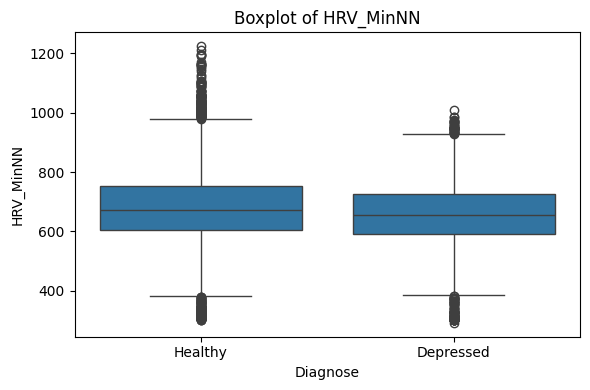

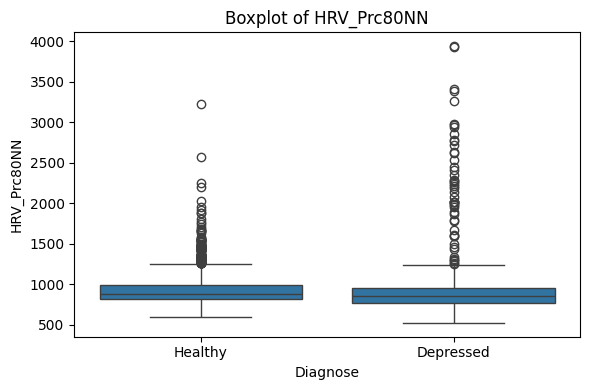

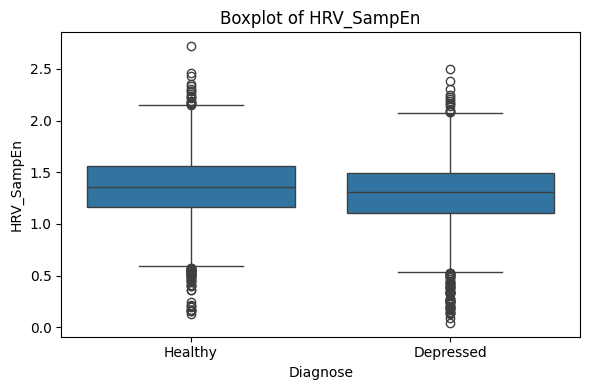

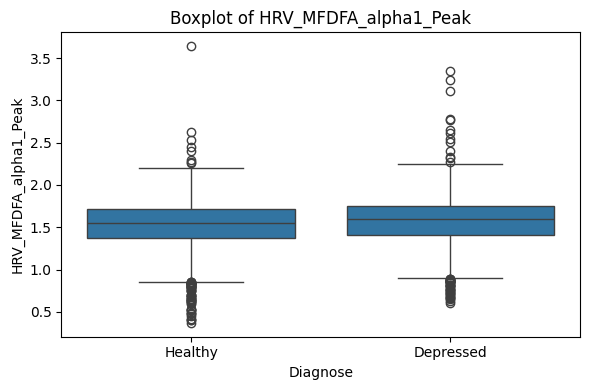

In [49]:
top_10_biosignal_features = get_top_biosignal_features(df_3M, target_col="Diagnose")
print(f"3 Minute important features:  {top_10_biosignal_features}\n")

plot_boxplots(df_3M, top_10_biosignal_features, label_col='Diagnose')

5 Minute important features:  ['HRV_Prc20NN', 'HRV_MedianNN', 'HRV_IALS', 'HRV_MeanNN', 'HRV_PSS', 'HRV_PIP', 'HRV_MinNN', 'HRV_Prc80NN', 'HRV_MFDFA_alpha1_Peak', 'HRV_SampEn']



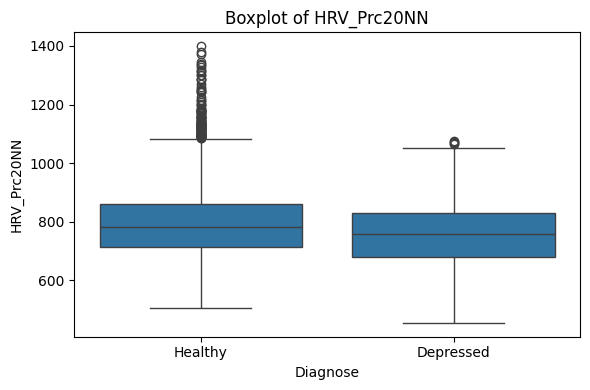

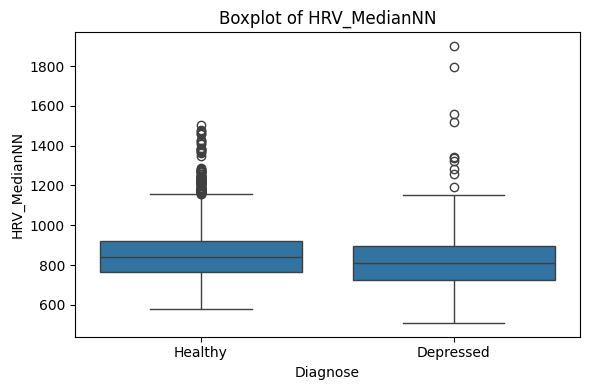

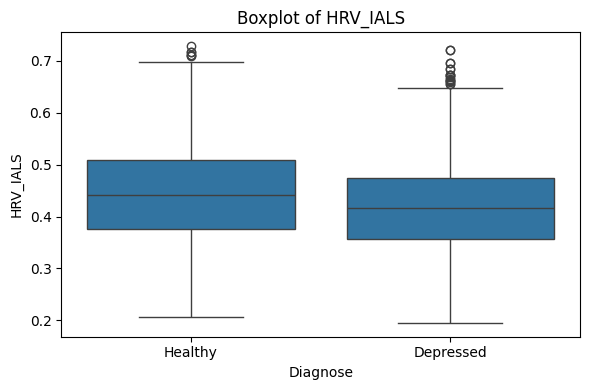

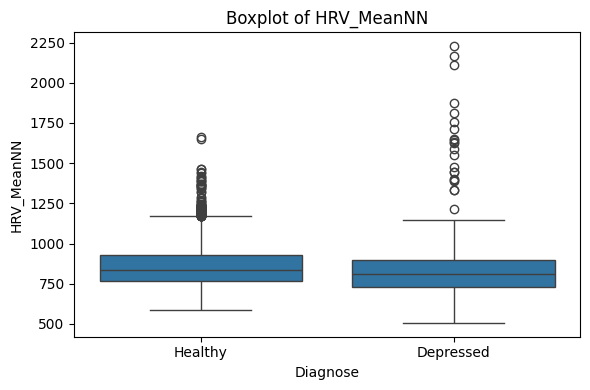

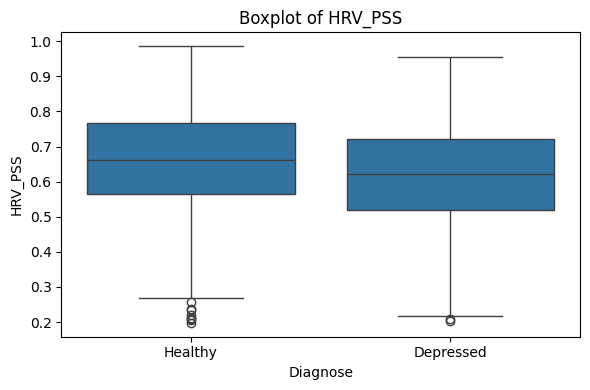

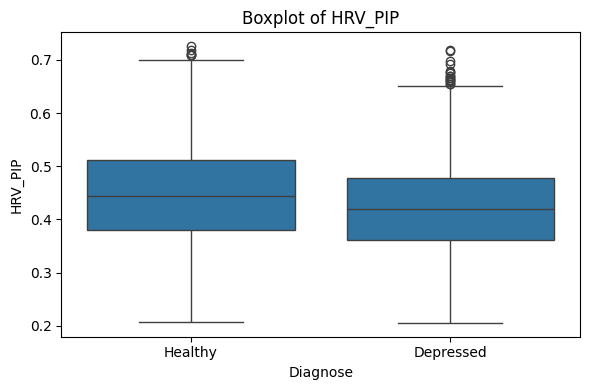

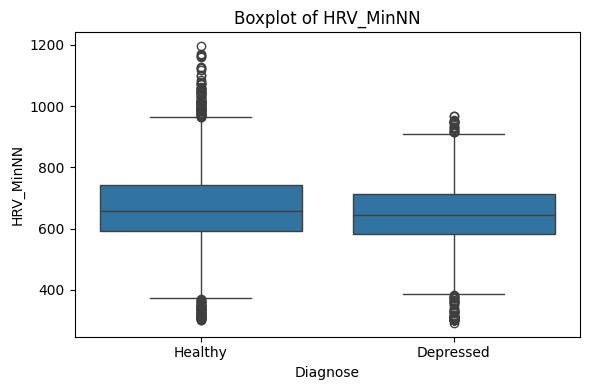

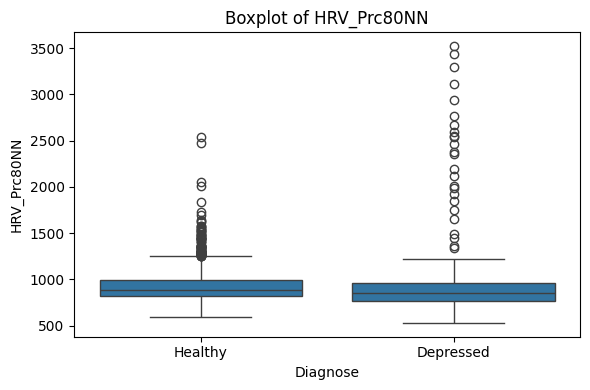

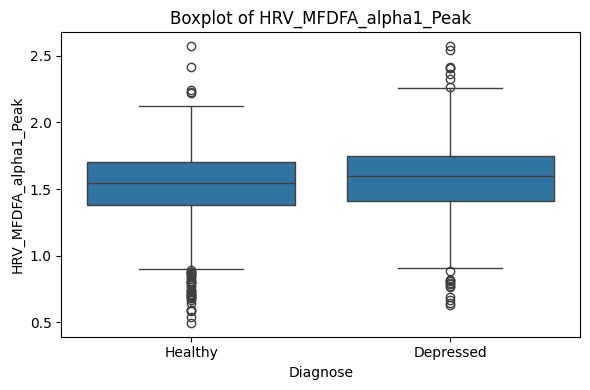

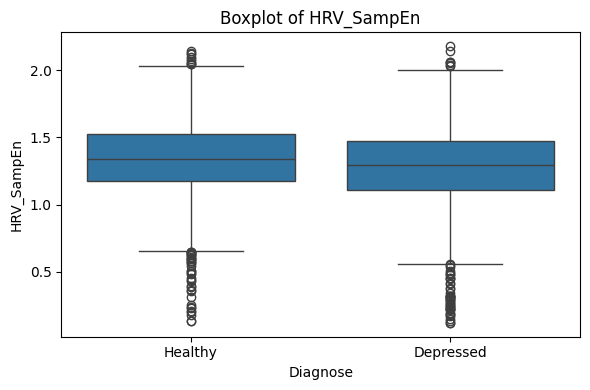

In [48]:

top_10_biosignal_features = get_top_biosignal_features(df_5M, target_col="Diagnose")
print(f"5 Minute important features:  {top_10_biosignal_features}\n")
plot_boxplots(df_5M, top_10_biosignal_features, label_col='Diagnose')